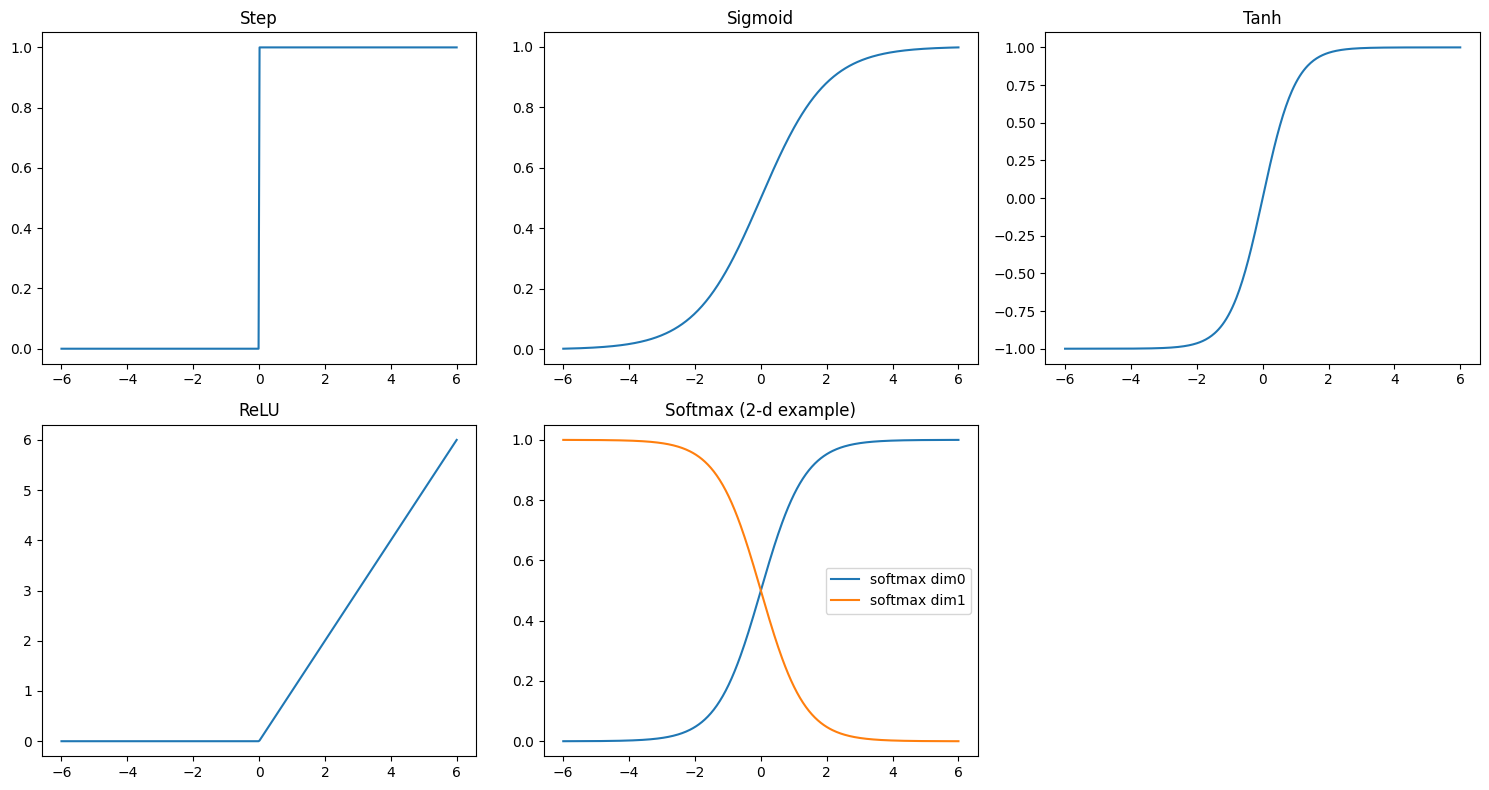

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

np.random.seed(42)

def step(x):
    return (x >= 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def tanh_deriv(x):
    return 1 - np.tanh(x)**2

def relu(x):
    return np.maximum(0, x)  #0 if neg else keep value

def relu_deriv(x):
    return (x > 0).astype(float)


def softmax(x):
    ex = np.exp(x - np.max(x, axis=1, keepdims=True))
    return ex / np.sum(ex, axis=1, keepdims=True)

# Plot activations
x = np.linspace(-6, 6, 400)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
axes[0].plot(x, step(x)); axes[0].set_title("Step")
axes[1].plot(x, sigmoid(x)); axes[1].set_title("Sigmoid")
axes[2].plot(x, tanh(x)); axes[2].set_title("Tanh")
axes[3].plot(x, relu(x)); axes[3].set_title("ReLU")

# softmax:across two values as one is varied
xs = np.vstack([x, -0.5 * x]).T
sm = softmax(xs)
axes[4].plot(x, sm[:, 0], label='softmax dim0'); axes[4].plot(x, sm[:, 1], label='softmax dim1')
axes[4].set_title("Softmax (2-d example)"); axes[4].legend()
axes[5].axis('off')
plt.tight_layout()
plt.show()

In [2]:
n_x = 2  #input
n_h = 6  #hidden neuron
n_y = 1  #output

def init_params(n_x, n_h, n_y):
    params = {
        'W1': np.random.randn(n_x, n_h) * 0.1,
        'b1': np.zeros((1, n_h)),
        'W2': np.random.randn(n_h, n_y) * 0.1,
        'b2': np.zeros((1, n_y))
    }
    return params

def forward(X, params):
    Z1 = X.dot(params['W1']) + params['b1']
    A1 = relu(Z1)
    Z2 = A1.dot(params['W2']) + params['b2']
    A2 = sigmoid(Z2)
    cache = {'X': X, 'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return A2, cache

def compute_loss(A2, Y):
    m = Y.shape[0]
    eps = 1e-9
    loss = - (1/m) * np.sum(Y * np.log(A2 + eps) + (1 - Y) * np.log(1 - A2 + eps))
    return loss

def backward(params, cache, Y):
    m = Y.shape[0]
    A2 = cache['A2']
    A1 = cache['A1']
    X = cache['X']
    dZ2 = A2 - Y
    dW2 = (1/m) * A1.T.dot(dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)
    dA1 = dZ2.dot(params['W2'].T)
    dZ1 = dA1 * relu_deriv(cache['Z1'])
    dW1 = (1/m) * X.T.dot(dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)
    grads = {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}
    return grads

def update_params(params, grads, lr):
    params['W1'] -= lr * grads['dW1']
    params['b1'] -= lr * grads['db1']
    params['W2'] -= lr * grads['dW2']
    params['b2'] -= lr * grads['db2']
    return params

In [3]:
learning_rate = 0.05
num_epochs = 2000
print_every = 200

def train(X_train, Y_train, X_val=None, Y_val=None, num_epochs=1000, lr=0.01):
    params = init_params(n_x, n_h, n_y)
    losses = []
    val_losses = []
    for epoch in range(1, num_epochs + 1):
        A2, cache = forward(X_train, params)
        loss = compute_loss(A2, Y_train)
        grads = backward(params, cache, Y_train)
        params = update_params(params, grads, lr)
        losses.append(loss)
        if X_val is not None:
            A2_val, _ = forward(X_val, params)
            val_losses.append(compute_loss(A2_val, Y_val))
        if epoch % print_every == 0 or epoch == 1:
            if X_val is not None and len(val_losses) > 0:
                print(f"Epoch {epoch}/{num_epochs} - loss: {loss:.4f} - val_loss: {val_losses[-1]:.4f}")
            else:
                print(f"Epoch {epoch}/{num_epochs} - loss: {loss:.4f}")
    return params, losses, val_losses

# Generate toy dataset
X, Y = make_moons(n_samples=1000, noise=0.2, random_state=42)
Y = Y.reshape(-1, 1).astype(float)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Train the model
params, losses, val_losses = train(X_train, Y_train, X_val=X_test, Y_val=Y_test,
                                  num_epochs=num_epochs, lr=learning_rate)

Epoch 1/2000 - loss: 0.6952 - val_loss: 0.6946
Epoch 200/2000 - loss: 0.5680 - val_loss: 0.5720
Epoch 400/2000 - loss: 0.3474 - val_loss: 0.3592
Epoch 600/2000 - loss: 0.3001 - val_loss: 0.3061
Epoch 800/2000 - loss: 0.2903 - val_loss: 0.2923
Epoch 1000/2000 - loss: 0.2876 - val_loss: 0.2877
Epoch 1200/2000 - loss: 0.2865 - val_loss: 0.2858
Epoch 1400/2000 - loss: 0.2858 - val_loss: 0.2848
Epoch 1600/2000 - loss: 0.2853 - val_loss: 0.2841
Epoch 1800/2000 - loss: 0.2847 - val_loss: 0.2835
Epoch 2000/2000 - loss: 0.2841 - val_loss: 0.2828


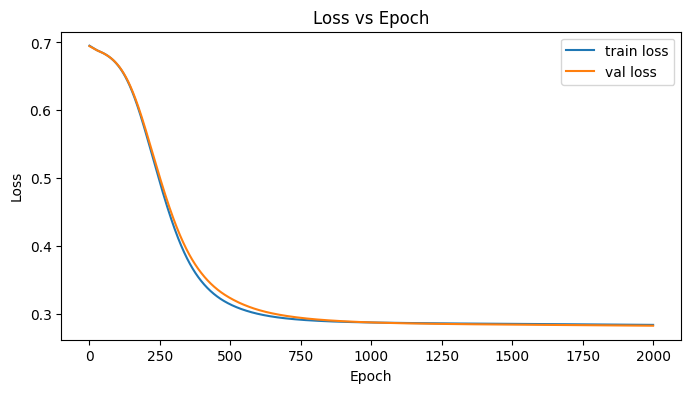

Test Accuracy: 0.8650
Test AUC: 0.9522


In [4]:


# Plot Loss vs Epoch
plt.figure(figsize=(8,4))
plt.plot(losses, label='train loss')
plt.plot(val_losses, label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

# Test model performance
A2_test, _ = forward(X_test, params)
y_pred_proba = A2_test.ravel()
y_pred = (y_pred_proba >= 0.5).astype(int).reshape(-1, 1)
acc = accuracy_score(Y_test, y_pred)
auc = roc_auc_score(Y_test, y_pred_proba)
print(f"Test Accuracy: {acc:.4f}")
print(f"Test AUC: {auc:.4f}")

